In [34]:
library(dplyr)

merged_data <- read.delim(
  "/home/mjehangir/telomere-sv-analysis/data/SV_CNV_TEL_merged_data.tsv",
  sep = "\t", header = TRUE, stringsAsFactors = FALSE, check.names = FALSE
)

dim(merged_data)
head(merged_data)


[1] 2388   17

,type,chr,Sample_ID,arm.x,arm_size,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,chr_arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,direction,TL_group
,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>,<chr>
1,DEL,chr1,2436A,p,124048267,581,0.201164,124.0483,4.683661,0.001621659,chr1p,5221.000,1,p,5.221000,Negative,Other
2,DEL,chr1,2436A,q,124339061,551,0.173200,124.3391,4.431431,0.001392965,chr1q,5051.167,1,q,5.051167,Negative,Other
3,DEL,chr1,3188,p,124048267,330,389.636135,124.0483,2.660255,3.141004259,chr1p,1642.500,1,p,1.642500,Negative,Short TL
4,DEL,chr1,3188,q,124339061,378,82.339694,124.3391,3.040074,0.662219043,chr1q,3086.500,1,q,3.086500,Negative,Short TL
5,DEL,chr1,3988,p,124048267,523,0.256730,124.0483,4.216101,0.002069598,chr1p,2347.500,1,p,2.347500,Negative,Other
6,DEL,chr1,3988,q,124339061,459,0.194912,124.3391,3.691519,0.001567585,chr1q,5083.000,1,q,5.083000,Negative,Other


In [35]:
#install.packages("clubSandwich")

In [36]:
library(dplyr)
library(ggplot2)
library(lme4)
library(lmerTest)
library(broom.mixed)
library(ggpubr)

t2t_genome_bp <- 3117292070
t2t_genome_mb <- t2t_genome_bp / 1e6

dat <- merged_data %>%
  mutate(
    sv_count    = as.numeric(sv_count),
    sv_size_sum = as.numeric(sv_size_sum),

    Sample_ID = factor(Sample_ID),
    chr_arm   = factor(chr_arm),
    type      = factor(type),
    TL_group  = factor(TL_group, levels = c("Short TL", "Other")),

    # whole-genome denominator versions (constant denom; keeps arm rows)
    sv_rate_wg = sv_count / t2t_genome_mb,

    # IMPORTANT: this assumes sv_size_sum is in Mb.
    # If sv_size_sum is in bp, change to: sv_size_sum / (t2t_genome_bp)
    sv_prop_wg = sv_size_sum / t2t_genome_mb
  )


In [37]:
make_mixed_plot <- function(dat, outcome, ylab, title) {

  d <- dat %>%
    mutate(y = log1p(.data[[outcome]])) %>%   # safe for zeros; also stabilizes variance
    filter(is.finite(y))

  # mixed model p-values per type (handles non-independence via (1|Sample_ID))
  pvals <- d %>%
    group_split(type) %>%
    lapply(function(dd) {
      fit <- lmer(y ~ TL_group + chr_arm + (1 | Sample_ID), data = dd)
      tt  <- broom.mixed::tidy(fit, effects = "fixed")
      # effect comparing Other vs Short TL (because we set levels)
      row <- tt[tt$term == "TL_groupOther", c("estimate","std.error","statistic","p.value")]
      row$type <- unique(dd$type)
      row
    }) %>%
    bind_rows()

  # y position per facet for the p-value bar/label
  ypos <- d %>%
    group_by(type) %>%
    summarise(y.position = max(y, na.rm = TRUE) * 1.08, .groups = "drop")

  pvals <- pvals %>%
    left_join(ypos, by = "type") %>%
    mutate(group1 = "Short TL", group2 = "Other", p = p.value)

  ggplot(d, aes(x = TL_group, y = y, color = TL_group)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.35, width = 0.6, size = 0.8) +
    geom_jitter(width = 0.15, size = 1, alpha = 0.6) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    ggpubr::stat_pvalue_manual(
      pvals, label = "p", tip.length = 0.01, size = 3
    ) +
    scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    labs(title = title, subtitle = "Arm-level points; p-values from mixed model (1|Sample_ID)",
         x = "Telomere Length Group", y = paste0("log(1 + ", ylab, ")")) +
    theme_minimal(base_size = 16) +
    theme(panel.grid = element_blank(),
          strip.text = element_text(face = "bold", size = 12),
          plot.title = element_text(face = "bold", size = 12, hjust = 0.5),
          plot.subtitle = element_text(size = 10, hjust = 0.5),
          legend.position = "none")
}


In [38]:
head(dat)

,type,chr,Sample_ID,arm.x,arm_size,sv_count,sv_size_sum,chr_length_mb,sv_rate,sv_proportion,chr_arm,final_average_TL_p75,chr_order,arm.y,final_average_TL_p75_kb,direction,TL_group,sv_rate_wg,sv_prop_wg
,<fct>,<chr>,<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<int>,<chr>,<dbl>,<chr>,<fct>,<dbl>,<dbl>
1,DEL,chr1,2436A,p,124048267,581,0.201164,124.0483,4.683661,0.001621659,chr1p,5221.000,1,p,5.221000,Negative,Other,0.1863797,6.453165e-05
2,DEL,chr1,2436A,q,124339061,551,0.173200,124.3391,4.431431,0.001392965,chr1q,5051.167,1,q,5.051167,Negative,Other,0.1767560,5.556104e-05
3,DEL,chr1,3188,p,124048267,330,389.636135,124.0483,2.660255,3.141004259,chr1p,1642.500,1,p,1.642500,Negative,Short TL,0.1058611,1.249919e-01
4,DEL,chr1,3188,q,124339061,378,82.339694,124.3391,3.040074,0.662219043,chr1q,3086.500,1,q,3.086500,Negative,Short TL,0.1212591,2.641385e-02
5,DEL,chr1,3988,p,124048267,523,0.256730,124.0483,4.216101,0.002069598,chr1p,2347.500,1,p,2.347500,Negative,Other,0.1677738,8.235674e-05
6,DEL,chr1,3988,q,124339061,459,0.194912,124.3391,3.691519,0.001567585,chr1q,5083.000,1,q,5.083000,Negative,Other,0.1472432,6.252606e-05


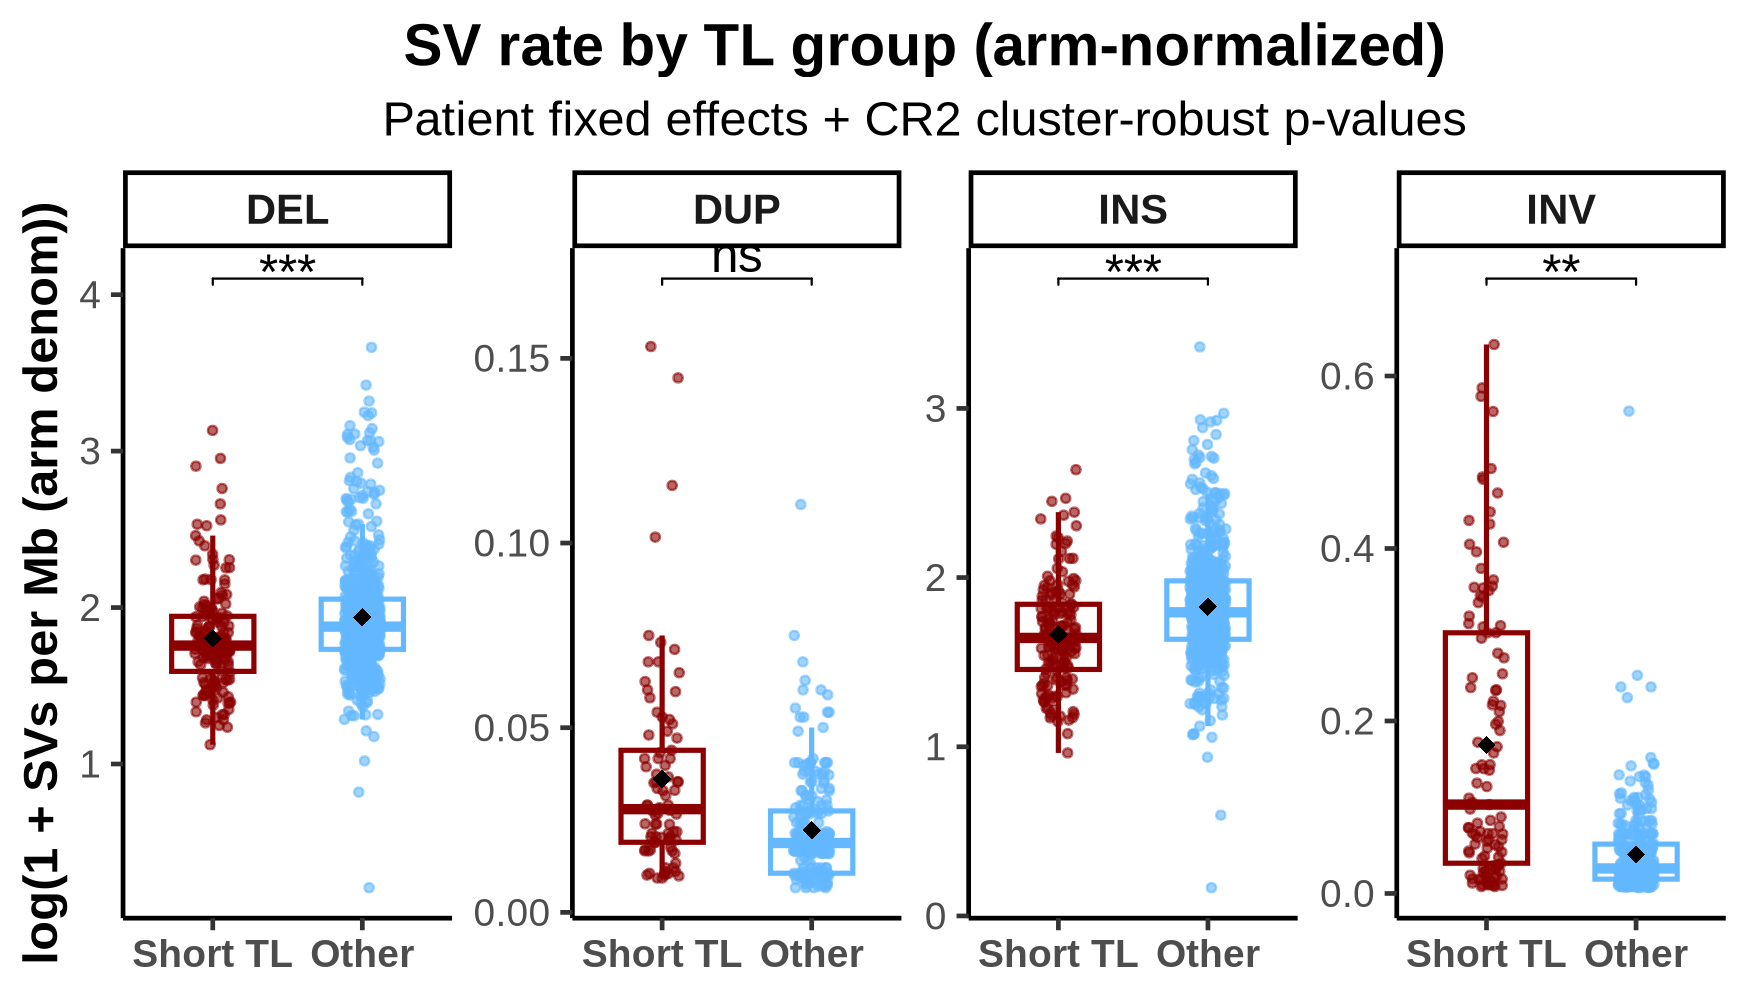

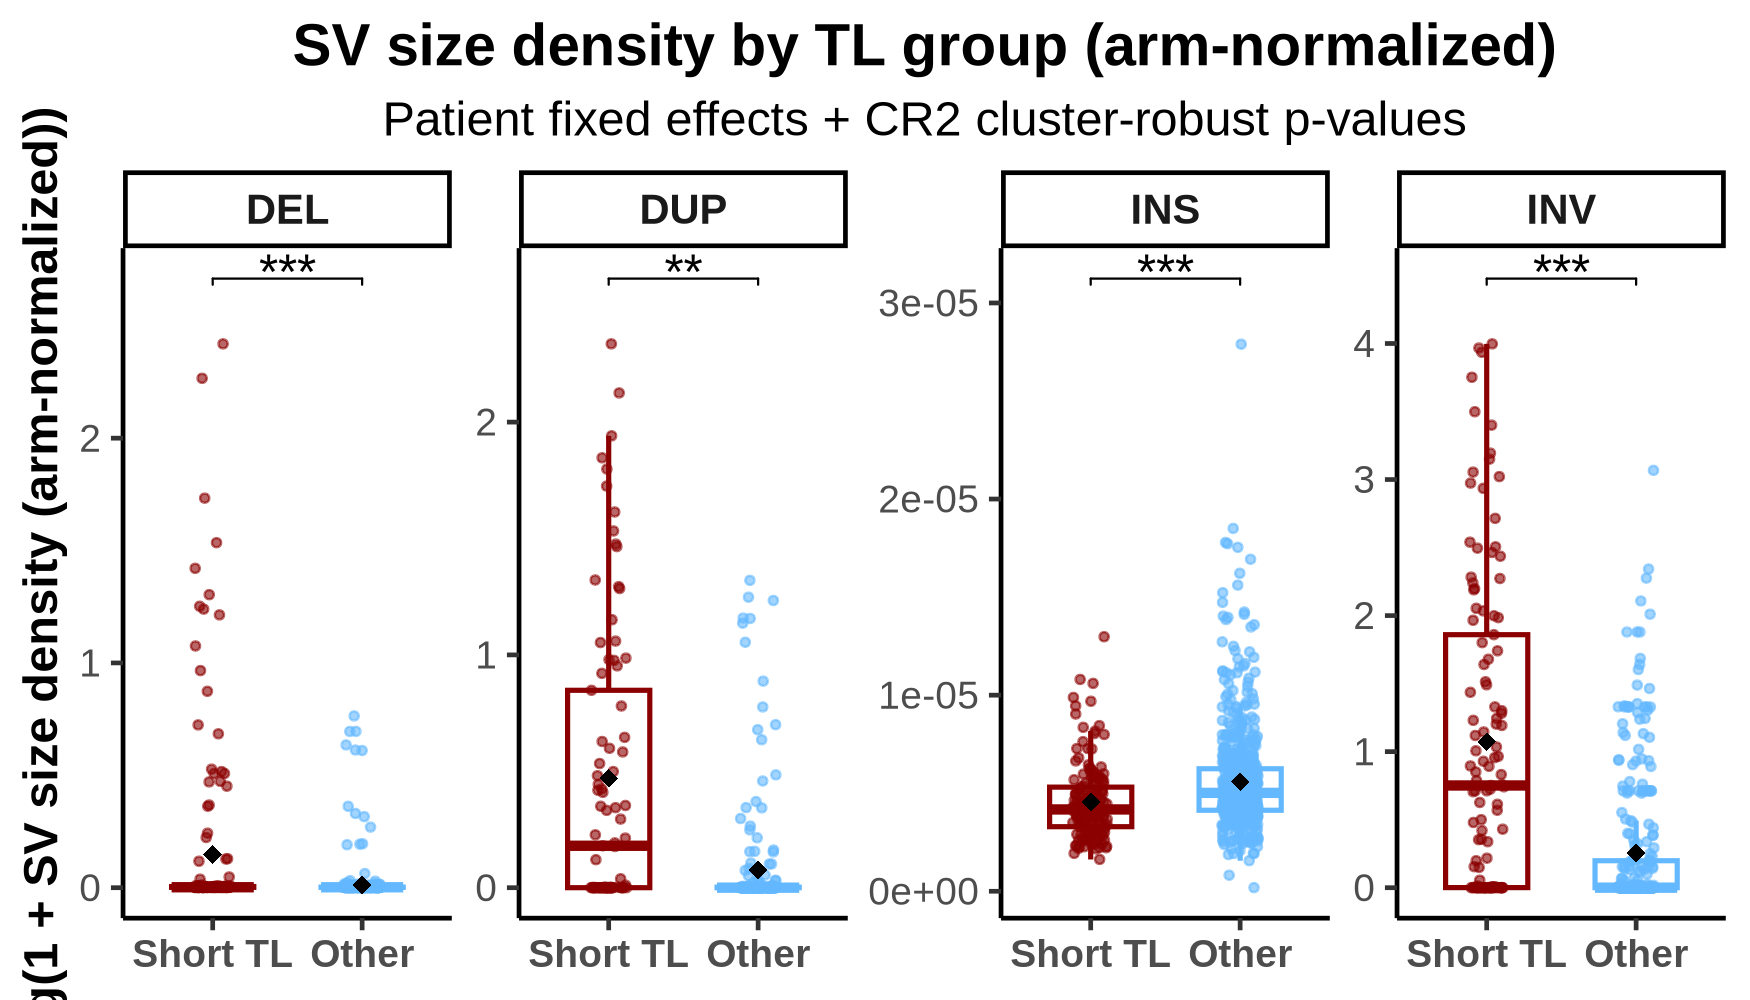

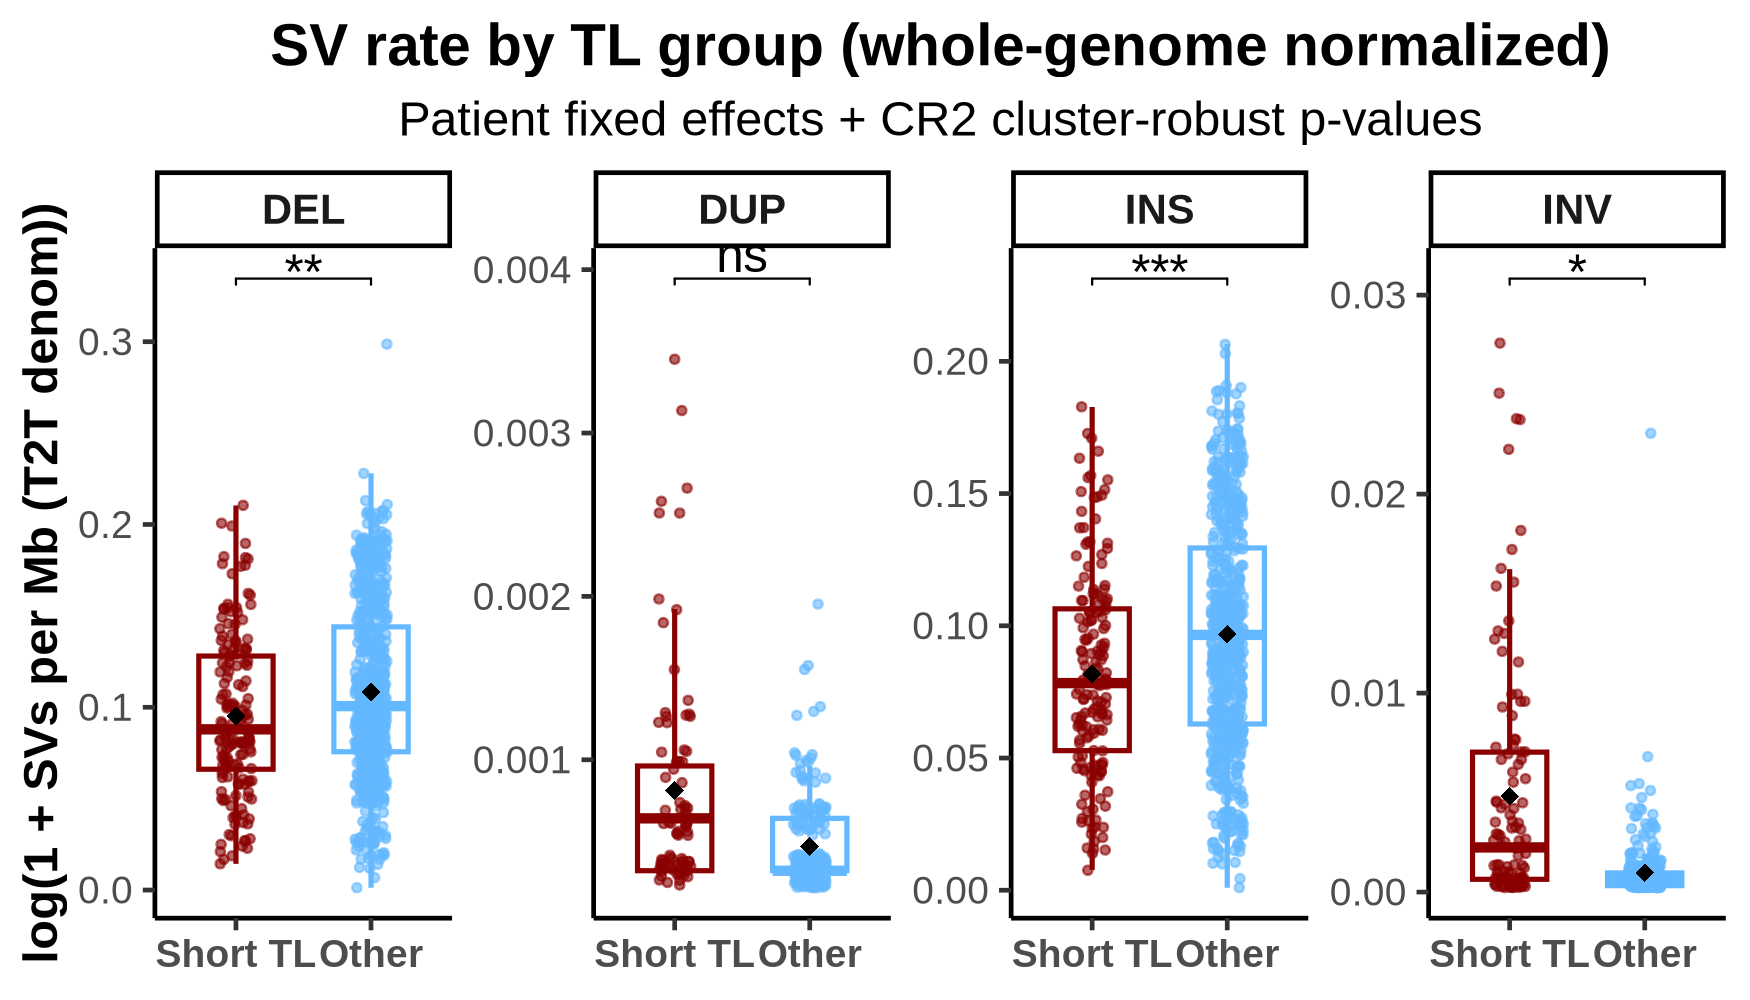

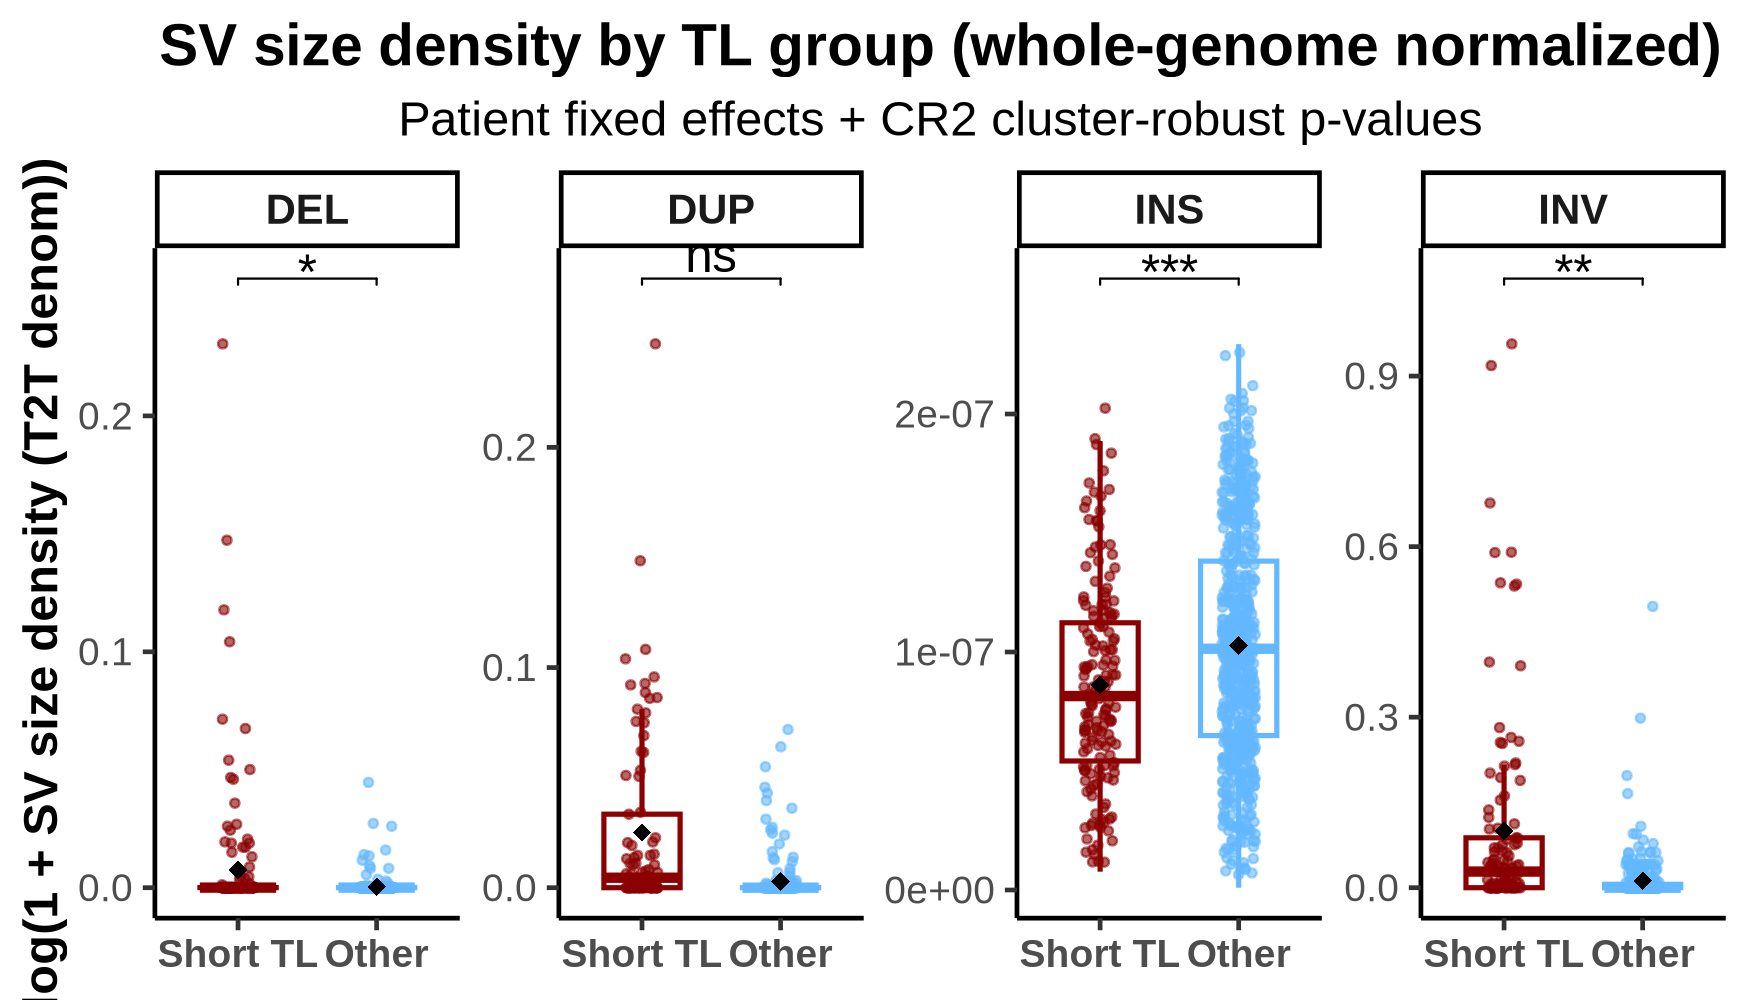

In [39]:
# Publication-quality plots + significance stars (***, **, *, ns)
# Assumes `dat` already exists and contains:
# type, Sample_ID, chr_arm, TL_group, sv_count, sv_rate, sv_proportion, sv_rate_wg, sv_prop_wg

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(ggpubr)
  library(clubSandwich)
})

p_to_stars <- function(p) {
  ifelse(is.na(p), "NA",
         ifelse(p < 0.001, "***",
                ifelse(p < 0.01, "**",
                       ifelse(p < 0.05, "*", "ns"))))
}

make_FE_plot_stars <- function(df, ycol, ylab, title_text) {

  d <- df %>%
    mutate(
      y_raw = as.numeric(.data[[ycol]]),
      y = log1p(y_raw),
      TL_group  = factor(TL_group, levels = c("Short TL", "Other")),
      Sample_ID = factor(Sample_ID),
      chr_arm   = factor(chr_arm),
      type      = factor(type)
    ) %>%
    filter(is.finite(y))

  # patient FIXED effects + CR2 cluster-robust p-values per type
  pvals <- d %>%
    group_split(type) %>%
    lapply(function(dd) {
      fit <- lm(y ~ TL_group + chr_arm + Sample_ID, data = dd)
      ct  <- clubSandwich::coef_test(fit, vcov = "CR2", cluster = dd$Sample_ID)

      p <- ct["TL_groupOther", "p_Satt"]
      data.frame(type = unique(dd$type), p = as.numeric(p))
    }) %>%
    bind_rows() %>%
    mutate(p.signif = p_to_stars(p))

  # y-position per facet for bracket/label
  ypos <- d %>%
    group_by(type) %>%
    summarise(y.position = max(y, na.rm = TRUE) * 1.12, .groups = "drop")

  pvals <- pvals %>%
    left_join(ypos, by = "type") %>%
    mutate(group1 = "Short TL", group2 = "Other")

  ggplot(d, aes(x = TL_group, y = y, color = TL_group)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.25, width = 0.55, linewidth = 0.7) +
    geom_jitter(width = 0.12, size = 0.9, alpha = 0.6) +
    stat_summary(fun = mean, geom = "point", shape = 18, size = 2.2, color = "black") +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    ggpubr::stat_pvalue_manual(
      pvals,
      label = "p.signif",   # <-- stars
      tip.length = 0.01,
      size = 5
    ) +
    scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    labs(
      title = title_text,
      subtitle = "Patient fixed effects + CR2 cluster-robust p-values",
      x = NULL,
      y = paste0("log(1 + ", ylab, ")")
    ) +
    theme_classic(base_size = 14) +
    theme(
      axis.title.y = element_text(face = "bold"),
      axis.text.x  = element_text(face = "bold"),
      strip.text   = element_text(face = "bold", size = 12),
      plot.title   = element_text(face = "bold", hjust = 0.5),
      plot.subtitle= element_text(hjust = 0.5),
      legend.position = "none"
    )
}

options(repr.plot.width = 7, repr.plot.height = 4, repr.plot.res = 250)

# --- 3 arm-normalized plots ---
#p_arm_count <- make_FE_plot_stars(dat, "sv_count", "SV count",
                                 # "SV counts by TL group (arm-level rows)")
p_arm_rate  <- make_FE_plot_stars(dat, "sv_rate", "SVs per Mb (arm denom)",
                                  "SV rate by TL group (arm-normalized)")
p_arm_prop  <- make_FE_plot_stars(dat, "sv_proportion", "SV size density (arm-normalized)",
                                  "SV size density by TL group (arm-normalized)")

# --- 3 whole-genome normalized plots ---
#p_wg_count <- make_FE_plot_stars(dat, "sv_count", "SV count",
                                # "SV counts by TL group (FE+robust inference)")
p_wg_rate  <- make_FE_plot_stars(dat, "sv_rate_wg", "SVs per Mb (T2T denom)",
                                 "SV rate by TL group (whole-genome normalized)")
p_wg_prop  <- make_FE_plot_stars(dat, "sv_prop_wg", "SV size density (T2T denom)",
                                 "SV size density by TL group (whole-genome normalized)")

#print(p_arm_count); print(p_arm_rate); print(p_arm_prop)
#print(p_wg_count);  print(p_wg_rate);  print(p_wg_prop)
print(p_arm_rate); print(p_arm_prop)
print(p_wg_rate);  print(p_wg_prop)
# Optional save (edit filenames/paths)
# ggsave("ARM_sv_count_stars.pdf", p_arm_count, width=7, height=4, dpi=300, useDingbats=FALSE)
# ggsave("ARM_sv_rate_stars.pdf",  p_arm_rate,  width=7, height=4, dpi=300, useDingbats=FALSE)
# ggsave("ARM_sv_prop_stars.pdf",  p_arm_prop,  width=7, height=4, dpi=300, useDingbats=FALSE)
# ggsave("WG_sv_count_stars.pdf",  p_wg_count,  width=7, height=4, dpi=300, useDingbats=FALSE)
# ggsave("WG_sv_rate_stars.pdf",   p_wg_rate,   width=7, height=4, dpi=300, useDingbats=FALSE)
# ggsave("WG_sv_prop_stars.pdf",   p_wg_prop,   width=7, height=4, dpi=300, useDingbats=FALSE)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


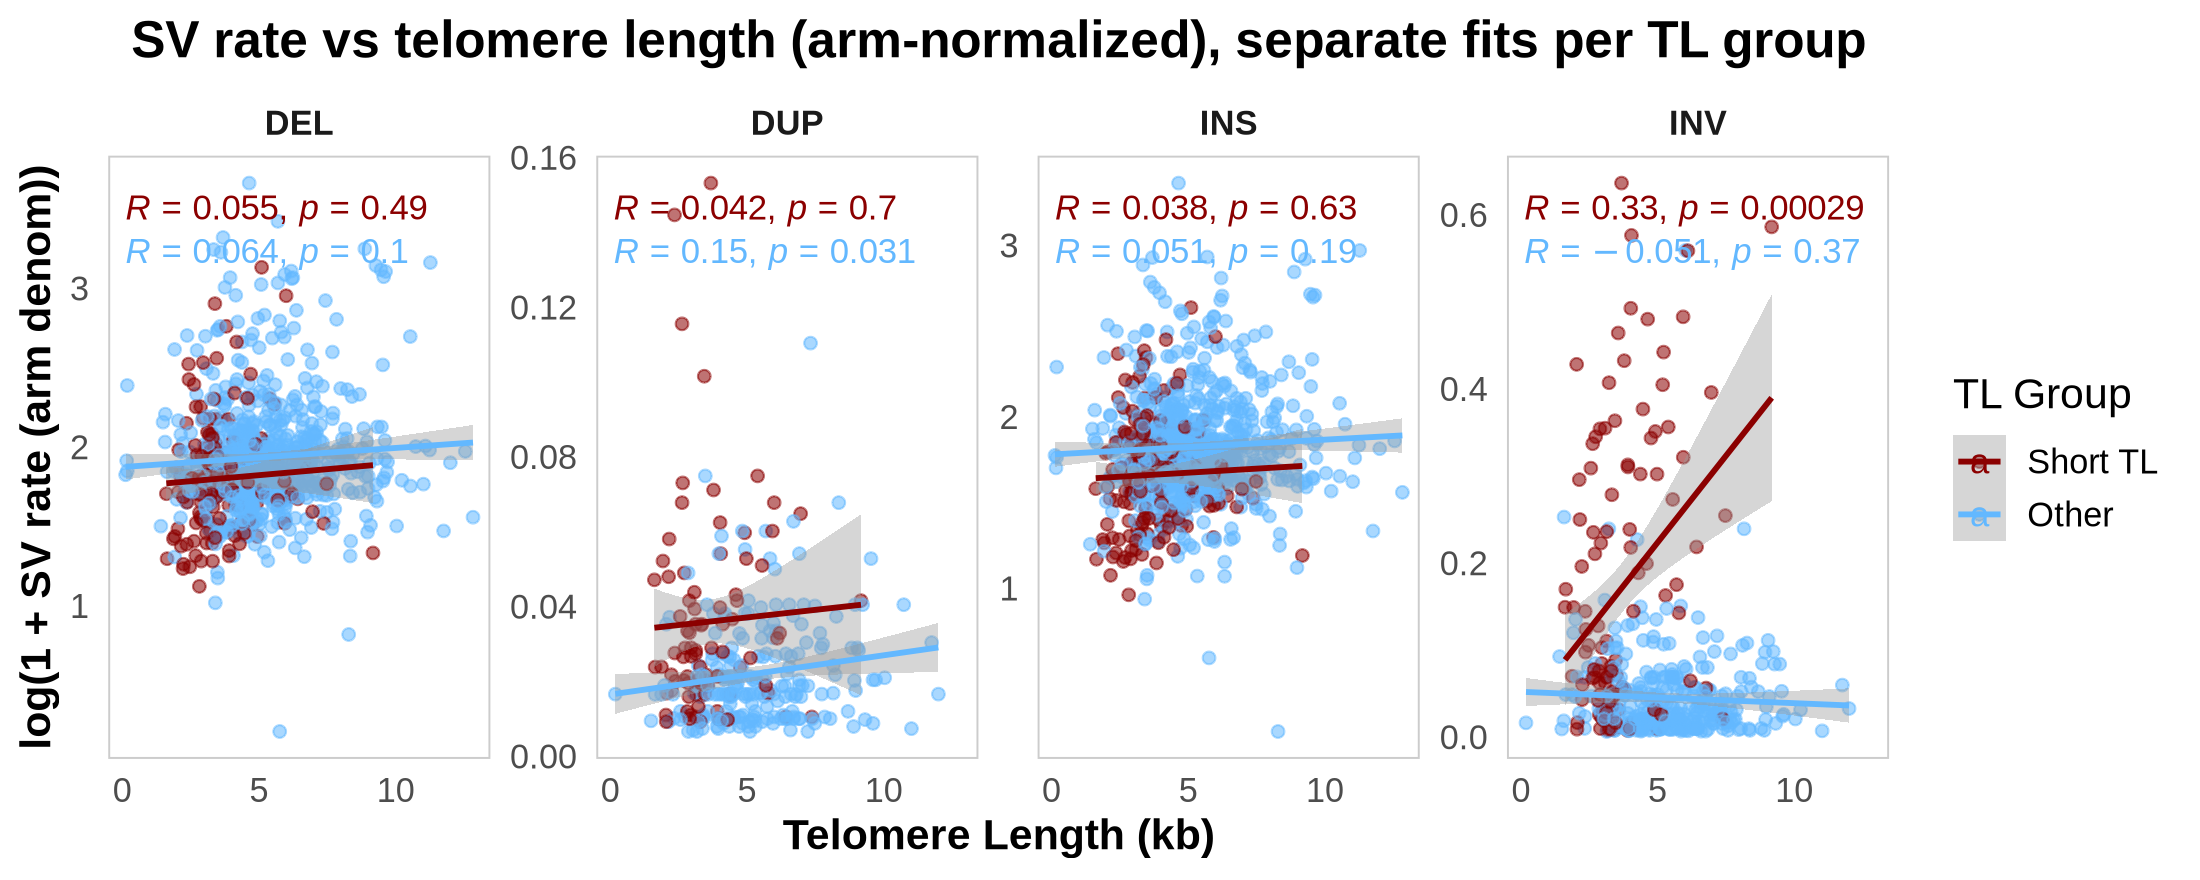

`geom_smooth()` using formula = 'y ~ x'


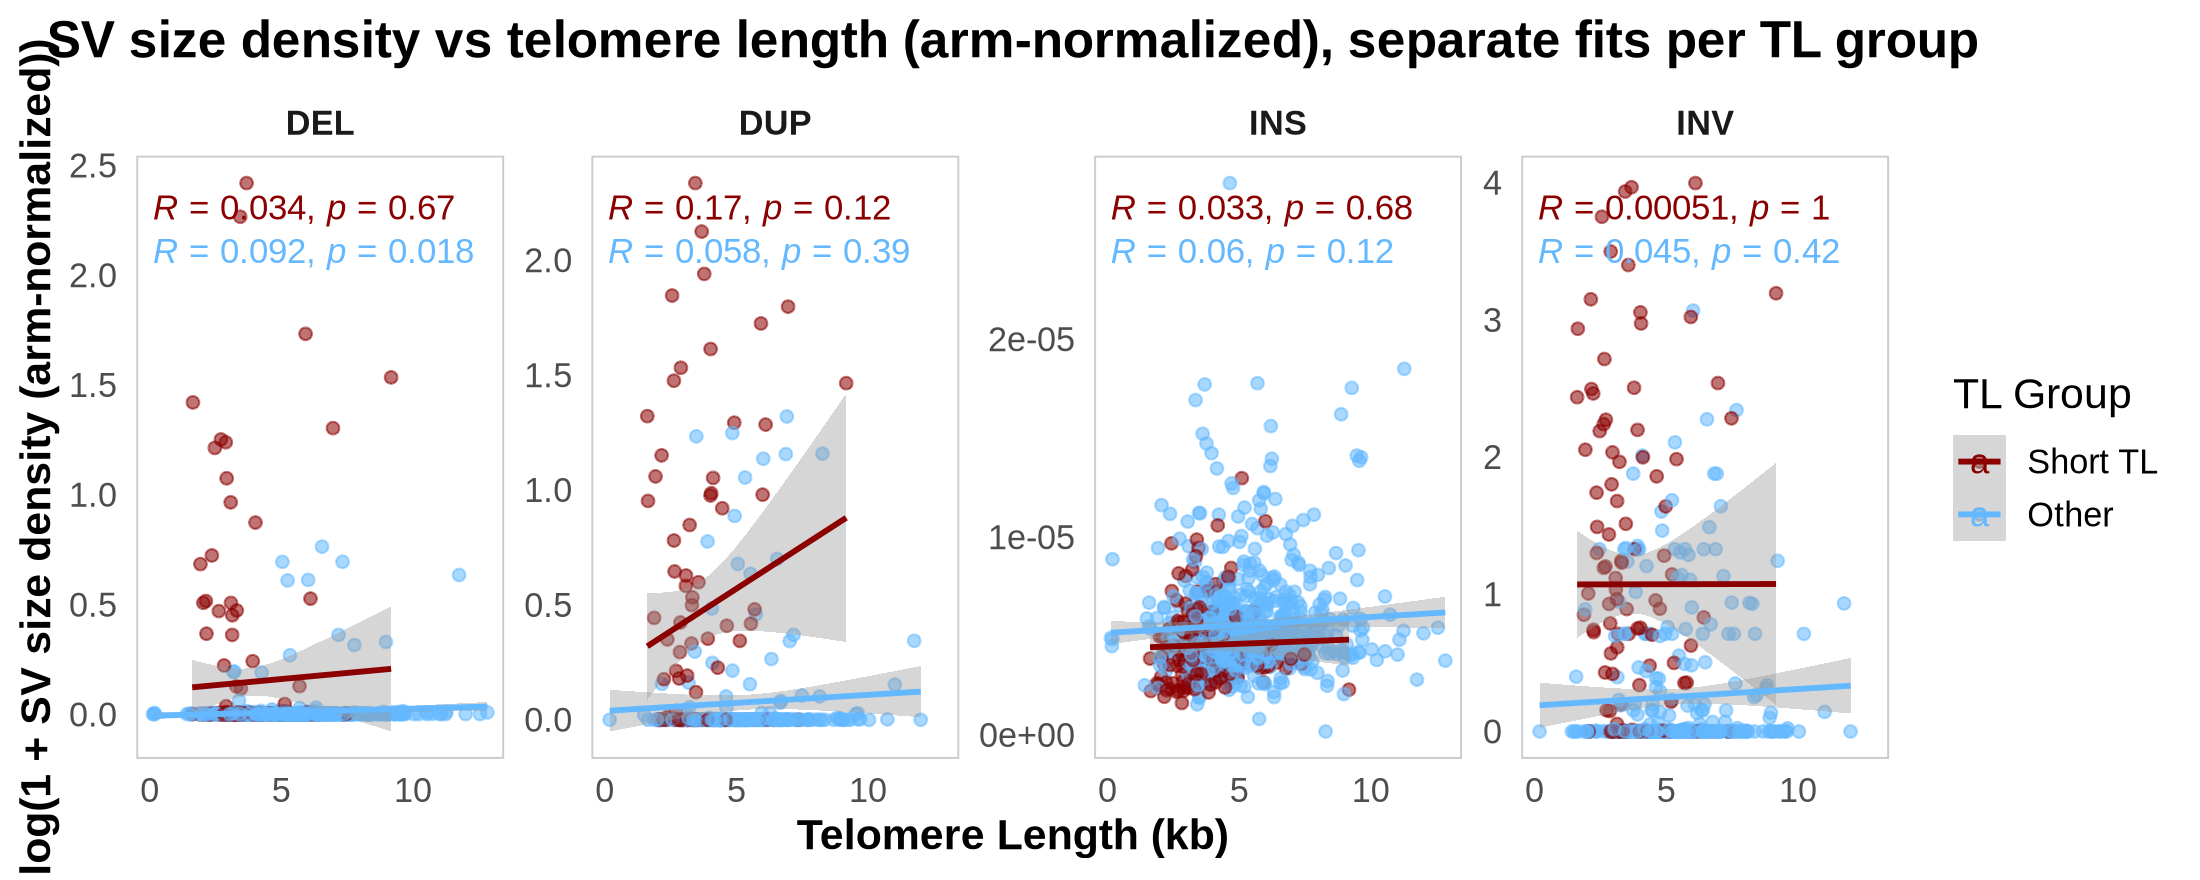

`geom_smooth()` using formula = 'y ~ x'


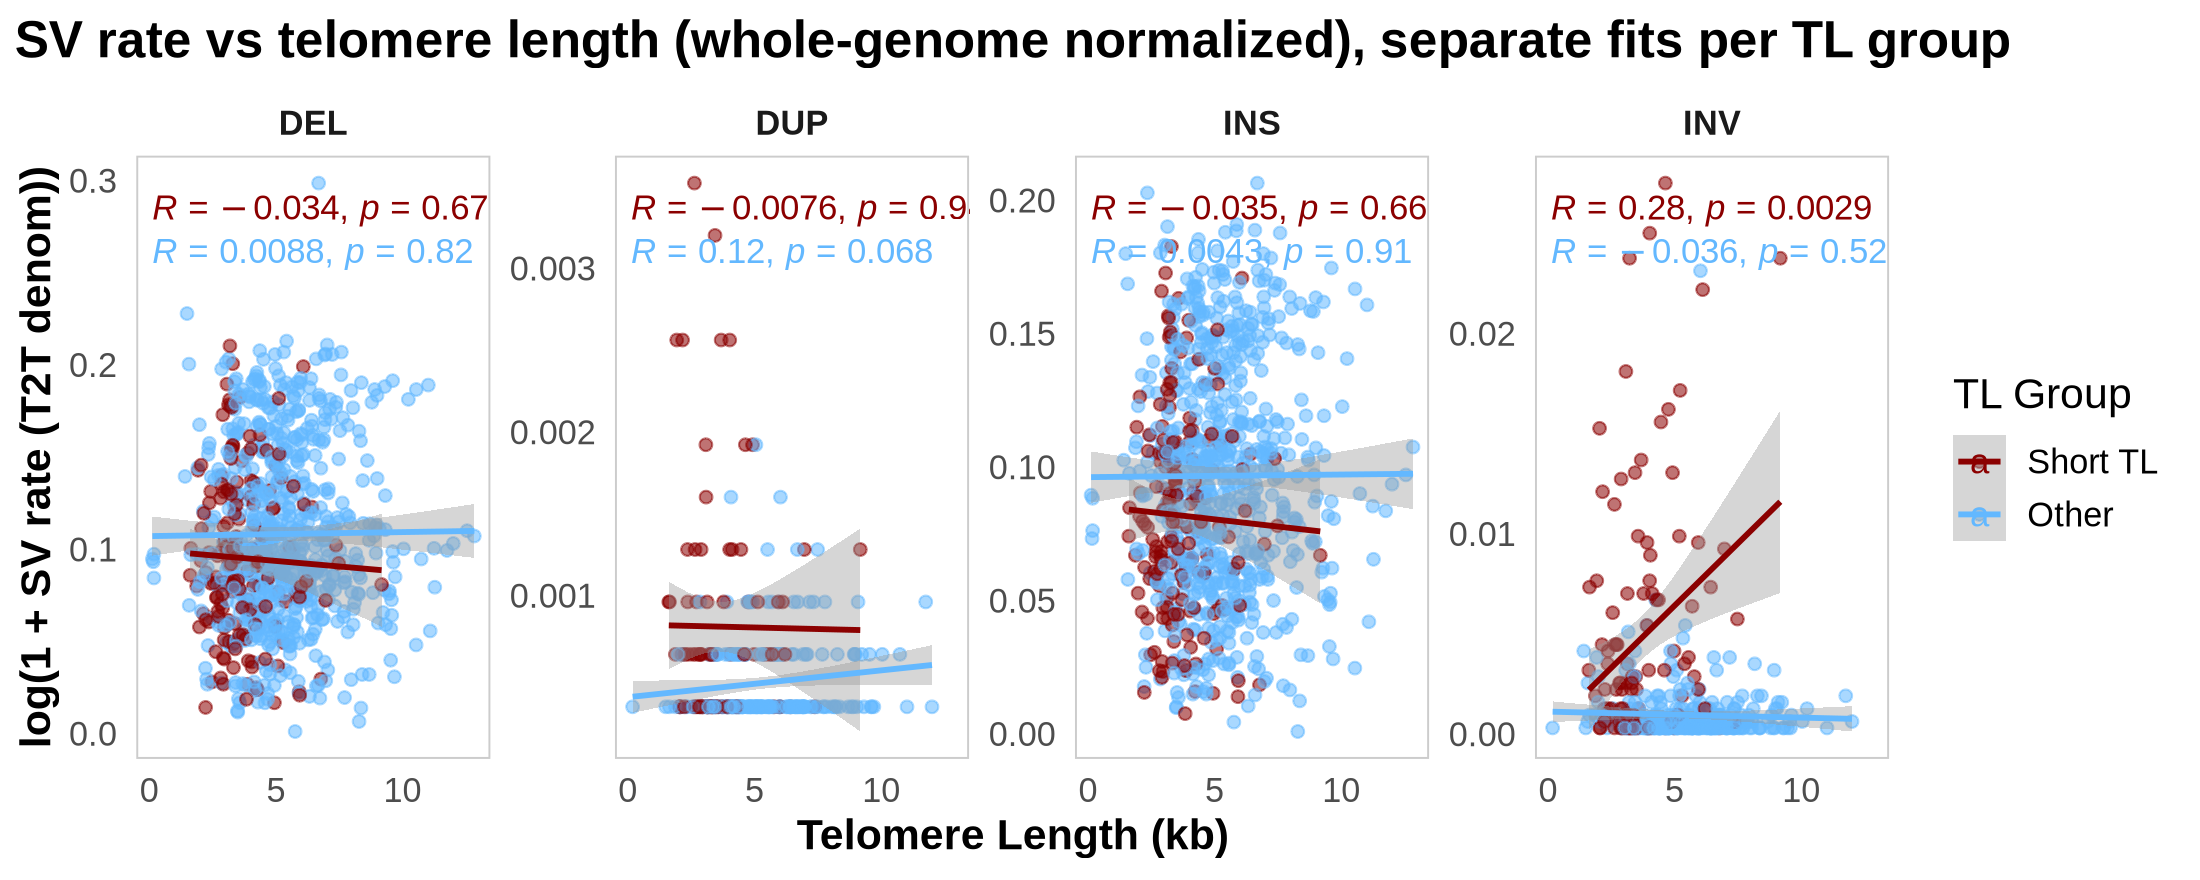

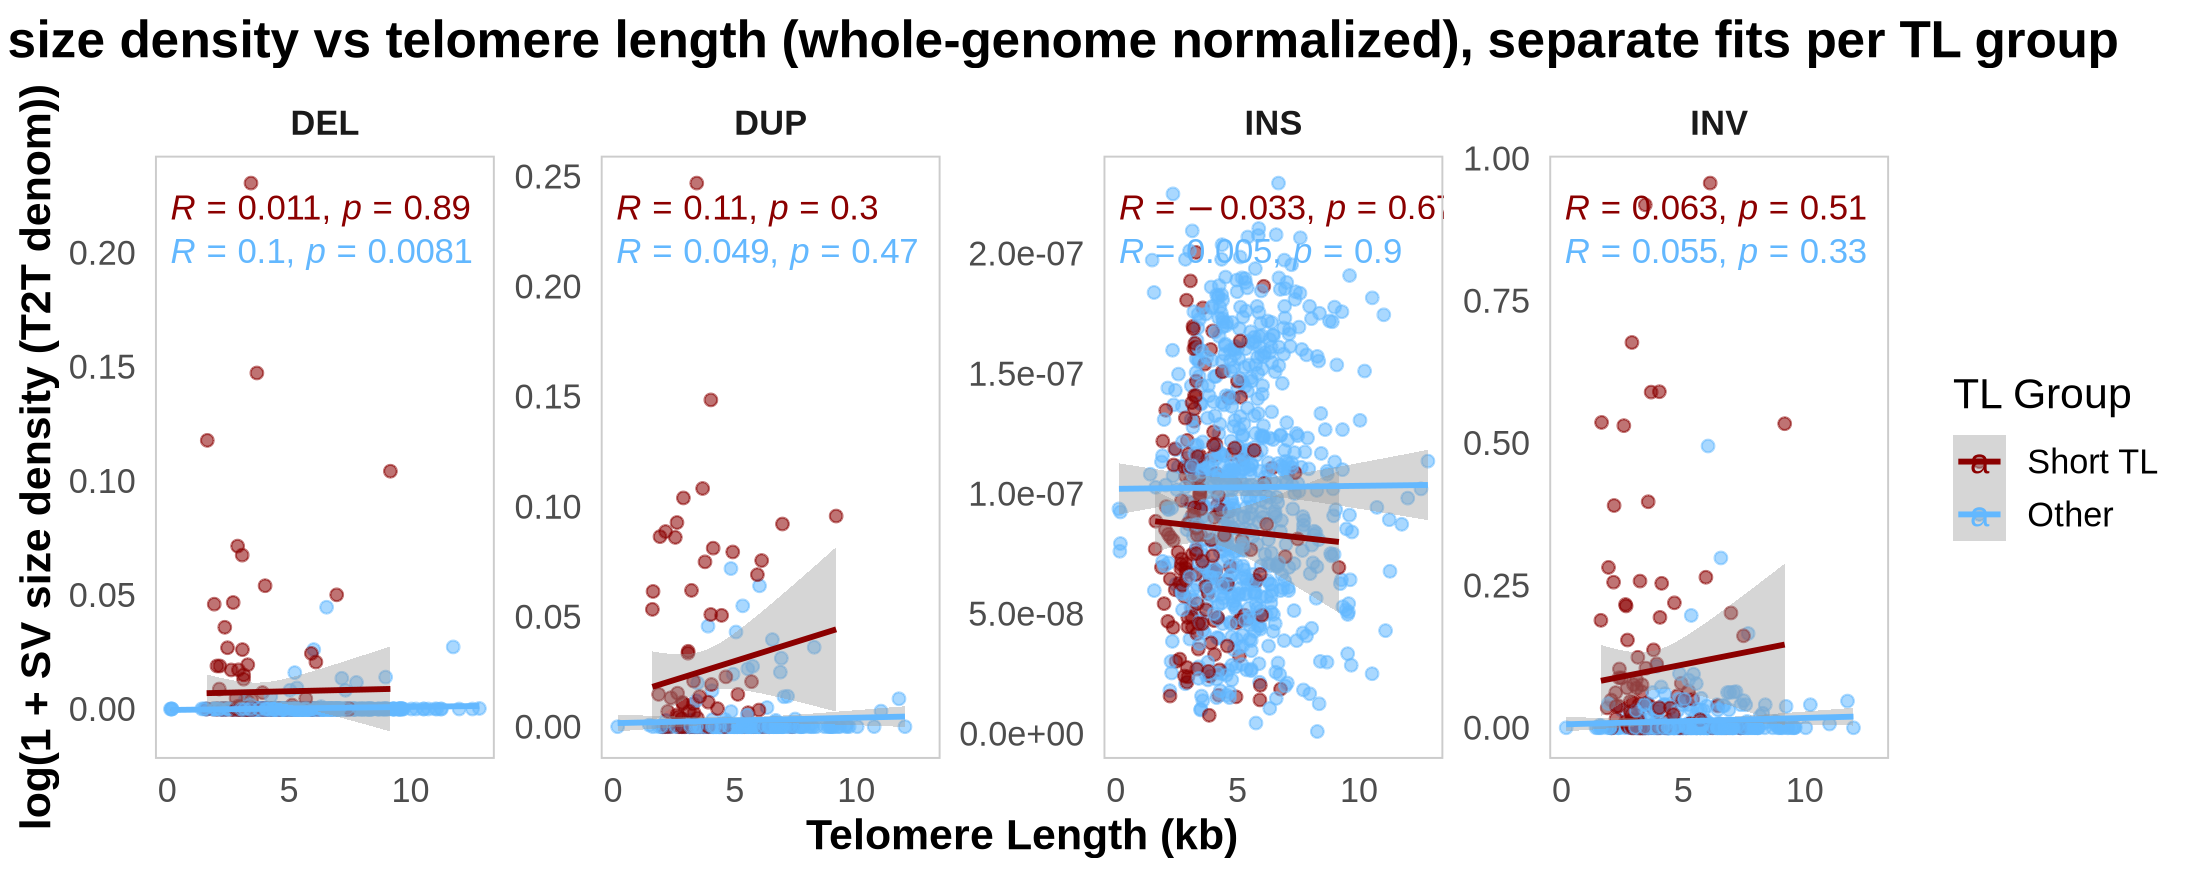

In [27]:
# Correlation scatterplots per SV type, with separate regression lines + r for each TL_group
# Works for BOTH arm-normalized and whole-genome normalized metrics

suppressPackageStartupMessages({
  library(dplyr)
  library(ggplot2)
  library(ggpubr)
})

make_corr_plot <- function(df, ycol, ylab, title_text) {

  d <- df %>%
    mutate(
      TL_kb   = as.numeric(final_average_TL_p75_kb),
      y_raw   = as.numeric(.data[[ycol]]),
      y       = log1p(y_raw),  # use log1p to avoid -Inf at 0
      TL_group = factor(TL_group, levels = c("Short TL", "Other")),
      type     = factor(type)
    ) %>%
    filter(is.finite(TL_kb), is.finite(y))

  ggplot(d, aes(x = TL_kb, y = y, color = TL_group)) +
    geom_point(size = 1.6, alpha = 0.55) +
    geom_smooth(method = "lm", se = TRUE, linewidth = 0.9) +
    ggpubr::stat_cor(
      aes(color = TL_group),
      method = "pearson",
      label.y.npc = "top",
      size = 4
    ) +
    facet_wrap(~ type, nrow = 1, scales = "free_y") +
    scale_color_manual(values = c("Short TL" = "darkred", "Other" = "steelblue1")) +
    labs(
      title = title_text,
      x = "Telomere Length (kb)",
      y = paste0("log(1 + ", ylab, ")"),
      color = "TL Group"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      panel.border = element_rect(fill = NA, color = "grey80", linewidth = 0.6),
      axis.title = element_text(face = "bold"),
      strip.text = element_text(face = "bold"),
      plot.title = element_text(face = "bold", hjust = 0.5),
      legend.position = "right"
    )
}

options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 220)

# ---- ARM-normalized correlation plots ----
p_corr_arm_rate <- make_corr_plot(dat, "sv_rate",
  ylab = "SV rate (arm denom)",
  title_text = "SV rate vs telomere length (arm-normalized), separate fits per TL group"
)

p_corr_arm_prop <- make_corr_plot(dat, "sv_proportion",
  ylab = "SV size density (arm-normalized)",
  title_text = "SV size density vs telomere length (arm-normalized), separate fits per TL group"
)

print(p_corr_arm_rate)
print(p_corr_arm_prop)

# ---- WHOLE-GENOME normalized correlation plots ----
p_corr_wg_rate <- make_corr_plot(dat, "sv_rate_wg",
  ylab = "SV rate (T2T denom)",
  title_text = "SV rate vs telomere length (whole-genome normalized), separate fits per TL group"
)

p_corr_wg_prop <- make_corr_plot(dat, "sv_prop_wg",
  ylab = "SV size density (T2T denom)",
  title_text = "SV size density vs telomere length (whole-genome normalized), separate fits per TL group"
)

print(p_corr_wg_rate)
print(p_corr_wg_prop)

# Optional save:
# ggsave("corr_arm_rate.pdf", p_corr_arm_rate, width=10, height=4, dpi=300, useDingbats=FALSE)
# ggsave("corr_arm_prop.pdf", p_corr_arm_prop, width=10, height=4, dpi=300, useDingbats=FALSE)
# ggsave("corr_wg_rate.pdf",  p_corr_wg_rate,  width=10, height=4, dpi=300, useDingbats=FALSE)
# ggsave("corr_wg_prop.pdf",  p_corr_wg_prop,  width=10, height=4, dpi=300, useDingbats=FALSE)
